<a href="https://colab.research.google.com/github/Dracarys38/Machyne-navchanya/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9C%D0%9D%2C_%D0%9F%D0%BE%D1%81%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D1%8F%D0%BA_%D0%86%D0%B3%D0%BE%D1%80_%D0%A1%D0%B5%D1%80%D0%B3%D1%96%D0%B9%D0%BE%D0%B2%D0%B8%D1%87_%D0%A4%D0%86%D0%A2_3_15%2C_10_%D0%B2%D0%B0%D1%80%D1%96%D0%B0%D0%BD%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle pandas numpy matplotlib seaborn statsmodels scikit-learn tensorflow prophet

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

1. Завантаження датасету з Kaggle

In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)

# Введення облікових даних Kaggle
kaggle_username = input("Введіть ваш username Kaggle: ")
kaggle_key = input("Введіть ваш key Kaggle: ")

# Створення файлу конфігурації
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Завантаження датасету
!kaggle datasets download -d yug201/daily-climate-time-series-data-delhi-india
!unzip -o daily-climate-time-series-data-delhi-india.zip

# Завантаження CSV-файлу
df = pd.read_csv('kaggel_weather_2013_to_2024.csv')
print("Дані успішно завантажено!")
print("Колонки датасету:", df.columns.tolist())
print("\nПерші 5 рядків:")
print(df.head())


Введіть ваш username Kaggle: neverseegods
Введіть ваш key Kaggle: KGAT_d690ef86fb7646a471aa15fd3b2fb1aa
Dataset URL: https://www.kaggle.com/datasets/yug201/daily-climate-time-series-data-delhi-india
License(s): Attribution 4.0 International (CC BY 4.0)
daily-climate-time-series-data-delhi-india.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  daily-climate-time-series-data-delhi-india.zip
  inflating: kaggel_weather_2013_to_2024.csv  
Дані успішно завантажено!
Колонки датасету: ['Unnamed: 0', 'DATE', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 'humidity', 'precip', 'precipprob', 'precipcover', 'windspeed', 'sealevelpressure', 'conditions', 'Year', 'month', 'dayofweek', 'dayofyear', 'year-2000', 'weekofyear', 'tempmax_humidity', 'tempmin_humidity', 'temp_humidity', 'feelslikemax_humidity', 'feelslikemin_humidity', 'feelslike_humidity', 'temp_range', 'heat_index']

Перші 5 рядків:
   Unnamed: 0       DATE  tem

2. Попередня обробка даних

In [4]:
date_col = None
if 'DATE' in df.columns:
    date_col = 'DATE'
else:
    for col in df.columns:
        if 'date' in col.lower():
            date_col = col
            break
if date_col is None:
    raise ValueError("Не знайдено колонку з датою. Доступні колонки: " + str(df.columns.tolist()))
print(f"\nВикористовується колонка з датою: {date_col}")

df[date_col] = pd.to_datetime(df[date_col])

df = df.sort_values(date_col)

df.set_index(date_col, inplace=True)

print("\nКількість пропущених значень:\n", df.isnull().sum())

df.dropna(inplace=True)

df.info()
df.describe()


Використовується колонка з датою: DATE

Кількість пропущених значень:
 Unnamed: 0               0
tempmax                  0
tempmin                  0
temp                     0
feelslikemax             0
feelslikemin             0
feelslike                0
humidity                 0
precip                   0
precipprob               0
precipcover              0
windspeed                0
sealevelpressure         0
conditions               0
Year                     0
month                    0
dayofweek                0
dayofyear                0
year-2000                0
weekofyear               0
tempmax_humidity         0
tempmin_humidity         0
temp_humidity            0
feelslikemax_humidity    0
feelslikemin_humidity    0
feelslike_humidity       0
temp_range               0
heat_index               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3557 entries, 2013-04-14 to 2024-11-30
Data columns (total 28 columns):
 #   Column                 Non-Nu

,Unnamed: 0,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,precipprob,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
count,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,...,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000,3557.000000
mean,1778.000000,31.367501,20.076132,25.403374,34.280180,20.938769,27.306803,63.755440,2.459033,23.137475,...,19.269328,26.865898,1919.095583,1240.914352,1554.375926,2137.701105,1299.951985,1696.889528,11.291369,195.577670
std,1026.961781,7.073934,7.568531,7.325541,9.651743,9.004827,9.301636,18.129251,10.636255,42.177066,...,3.219299,14.910296,525.888218,580.706647,539.222716,839.862724,692.599628,754.644547,3.622231,55.583693
min,0.000000,9.100000,2.000000,6.500000,7.900000,0.300000,5.700000,16.100000,0.000000,0.000000,...,13.000000,1.000000,686.400000,181.200000,586.560000,636.480000,18.960000,560.880000,1.500000,73.465023
25%,889.000000,26.400000,13.000000,19.100000,26.300000,13.000000,19.100000,53.000000,0.000000,0.000000,...,17.000000,14.000000,1541.550000,759.360000,1119.820000,1534.400000,752.070000,1113.600000,8.300000,164.445621
50%,1778.000000,33.000000,22.000000,27.700000,35.400000,22.000000,28.400000,65.800000,0.000000,0.000000,...,20.000000,27.000000,1823.360000,1078.400000,1420.200000,1845.510000,1080.320000,1422.960000,11.600000,180.548686
75%,2667.000000,36.000000,26.900000,31.000000,42.700000,28.000000,35.400000,76.900000,0.000000,0.000000,...,22.000000,40.000000,2341.170000,1752.400000,2035.800000,2764.200000,1864.200000,2314.620000,14.100000,233.676622
max,3556.000000,47.900000,34.800000,39.500000,57.700000,41.100000,47.000000,99.300000,203.047000,100.000000,...,24.000000,53.000000,3180.720000,2581.600000,2710.680000,4617.200000,3273.740000,3727.950000,20.600000,352.198303


3. Дослідницький аналіз даних (EDA)

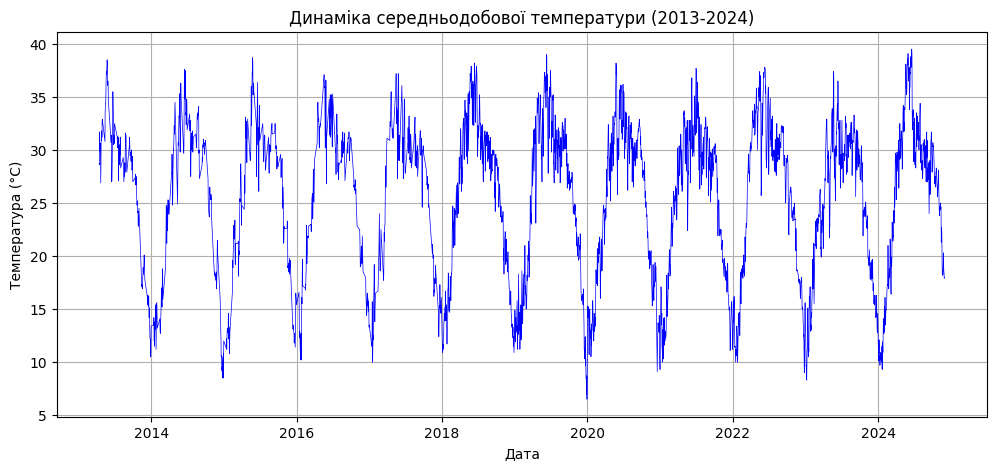

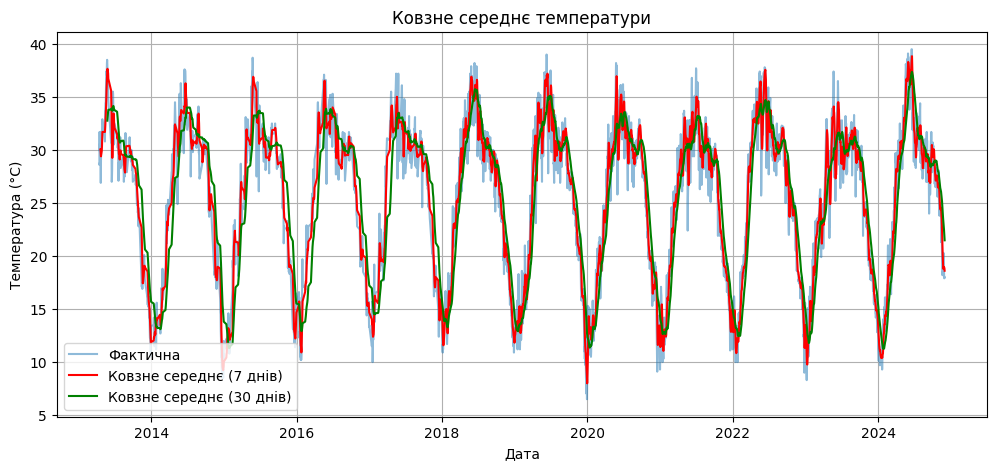

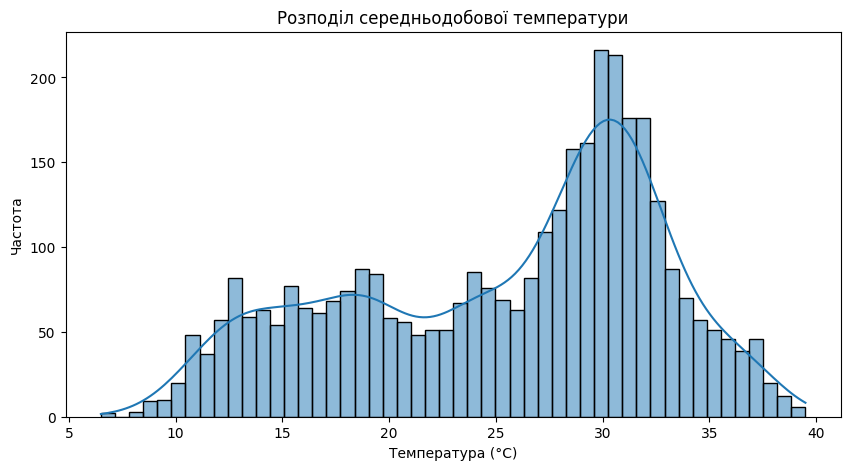

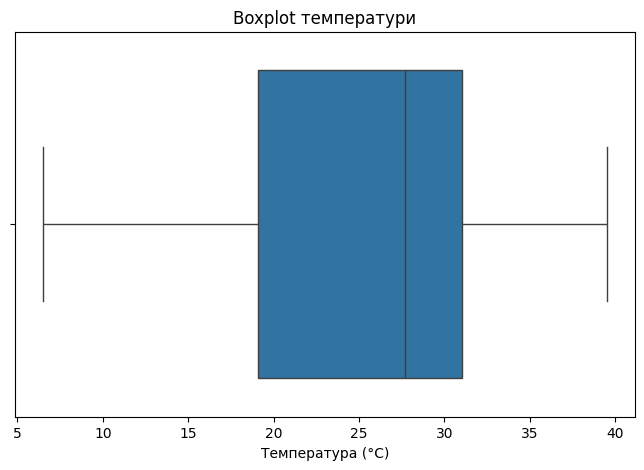

In [5]:
target = 'temp'
if target not in df.columns:
    raise ValueError(f"Колонка '{target}' не знайдена. Доступні: {df.columns.tolist()}")

plt.figure(figsize=(12,5))
plt.plot(df.index, df[target], color='blue', linewidth=0.5)
plt.title('Динаміка середньодобової температури (2013-2024)')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True)
plt.show()

df['rolling_7'] = df[target].rolling(window=7).mean()
df['rolling_30'] = df[target].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(df.index, df[target], label='Фактична', alpha=0.5)
plt.plot(df.index, df['rolling_7'], label='Ковзне середнє (7 днів)', color='red')
plt.plot(df.index, df['rolling_30'], label='Ковзне середнє (30 днів)', color='green')
plt.title('Ковзне середнє температури')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df[target], bins=50, kde=True)
plt.title('Розподіл середньодобової температури')
plt.xlabel('Температура (°C)')
plt.ylabel('Частота')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df[target])
plt.title('Boxplot температури')
plt.xlabel('Температура (°C)')
plt.show()


4. Аналіз автокореляції

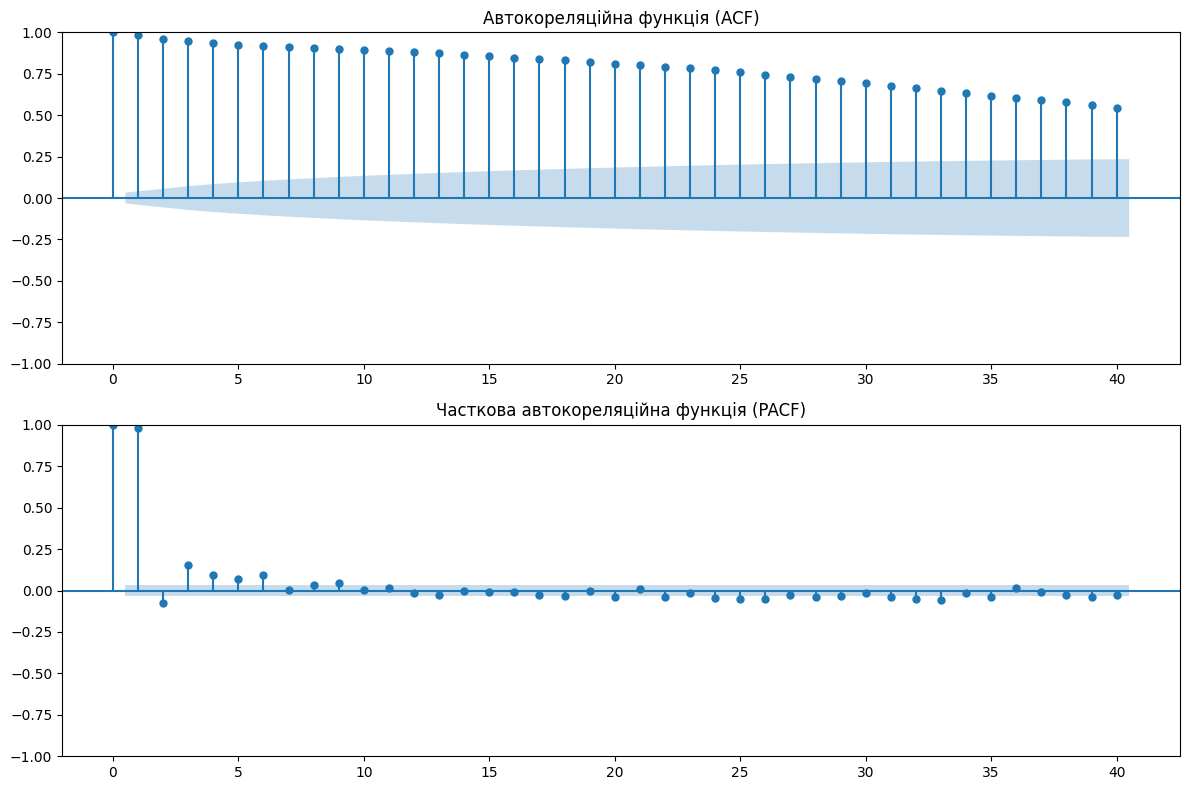

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8))
plot_acf(df[target], lags=40, ax=ax1, title='Автокореляційна функція (ACF)')
plot_pacf(df[target], lags=40, ax=ax2, title='Часткова автокореляційна функція (PACF)')
plt.tight_layout()
plt.show()

5. Підготовка даних для моделювання

In [7]:
train_size = int(len(df) * 0.8)
train, test = df[target].iloc[:train_size], df[target].iloc[train_size:]

print(f"\nРозмір тренувальної вибірки: {len(train)} днів")
print(f"Розмір тестової вибірки: {len(test)} днів")


Розмір тренувальної вибірки: 2845 днів
Розмір тестової вибірки: 712 днів


6. Модель ARIMA

In [8]:
model_arima = ARIMA(train, order=(1,1,1))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

# Прогноз на тестовий період
forecast_arima = model_arima_fit.forecast(steps=len(test))

# Оцінка метрик
mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mape_arima = np.mean(np.abs((test - forecast_arima) / test)) * 100

print(f"\nARIMA - MAE: {mae_arima:.2f}, RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2f}%")

                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 2845
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5037.762
Date:                Sun, 22 Mar 2026   AIC                          10081.523
Time:                        09:37:09   BIC                          10099.382
Sample:                             0   HQIC                         10087.964
                               - 2845                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3664      0.118     -3.108      0.002      -0.598      -0.135
ma.L1          0.4676      0.112      4.165      0.000       0.248       0.688
sigma2         2.0235      0.034     58.810      0.0

7. Модель Prophet

In [9]:
prophet_df = df.reset_index()

prophet_df = prophet_df.rename(columns={df.index.name: 'ds', target: 'y'})

train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet.fit(train_prophet)

future = model_prophet.make_future_dataframe(periods=len(test_prophet))
forecast_prophet = model_prophet.predict(future)

forecast_prophet_values = forecast_prophet.set_index('ds').loc[test_prophet['ds']]['yhat']

mae_prophet = mean_absolute_error(test_prophet['y'], forecast_prophet_values)
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], forecast_prophet_values))
mape_prophet = np.mean(np.abs((test_prophet['y'] - forecast_prophet_values) / test_prophet['y'])) * 100

print(f"Prophet - MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2f}%")

Prophet - MAE: 2.00, RMSE: 2.59, MAPE: nan%


8. Модель LSTM

In [10]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
test_scaled = scaler.transform(test.values.reshape(-1,1))

def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 30
X_train, y_train = create_sequences(train_scaled, lookback)
X_test, y_test = create_sequences(test_scaled, lookback)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(lookback, 1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

history = model_lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1,
                         callbacks=[EarlyStopping(patience=5)], verbose=1)

y_pred_scaled = model_lstm.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

mae_lstm = mean_absolute_error(y_true, y_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_true, y_pred))
mape_lstm = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"LSTM - MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}, MAPE: {mape_lstm:.2f}%")

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0231 - val_loss: 0.0061
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0093 - val_loss: 0.0054
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0084 - val_loss: 0.0058
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0079 - val_loss: 0.0085
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0076 - val_loss: 0.0048
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0072 - val_loss: 0.0048
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0073 - val_loss: 0.0045
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0071 - val_loss: 0.0050
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0065 - val_loss: 0.0048
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0066 - val_loss: 0.0041
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0063 - val_loss: 0.0041
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0

9. Візуалізація результатів

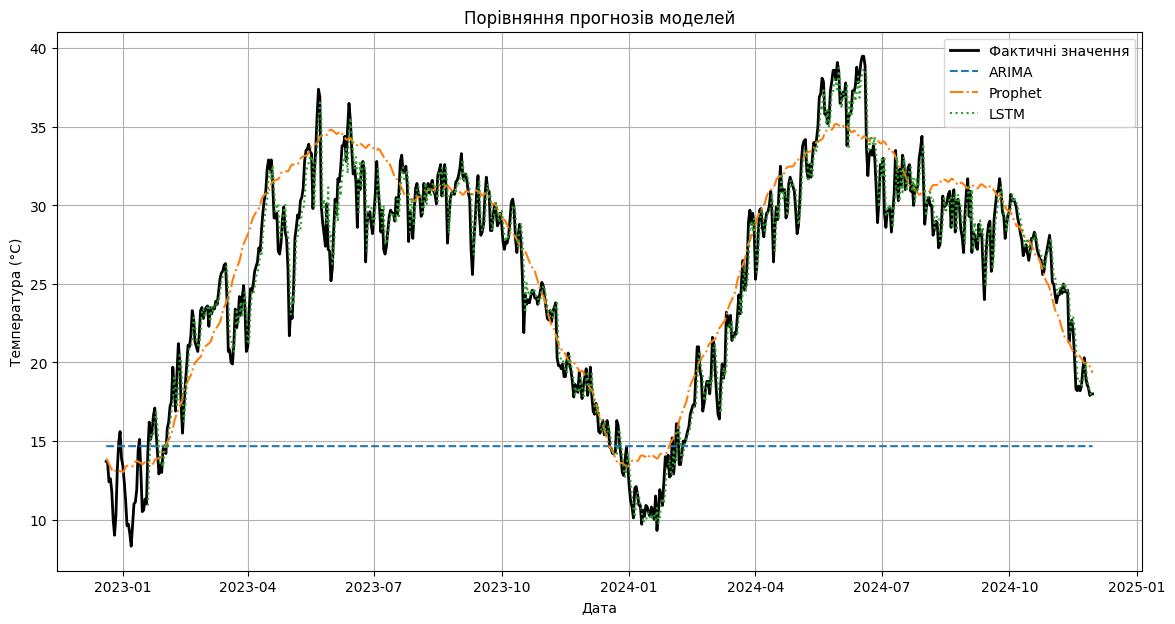

In [11]:
plt.figure(figsize=(14,7))
plt.plot(test.index, test, label='Фактичні значення', color='black', linewidth=2)

plt.plot(test.index, forecast_arima, label='ARIMA', linestyle='--')

plt.plot(test_prophet['ds'], forecast_prophet_values, label='Prophet', linestyle='-.')

lstm_dates = test.index[lookback:]
plt.plot(lstm_dates, y_pred, label='LSTM', linestyle=':')

plt.title('Порівняння прогнозів моделей')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True)
plt.show()

10. Порівняльна таблиця

In [12]:
results = pd.DataFrame({
    'Модель': ['ARIMA', 'Prophet', 'LSTM'],
    'MAE': [mae_arima, mae_prophet, mae_lstm],
    'RMSE': [rmse_arima, rmse_prophet, rmse_lstm],
    'MAPE (%)': [mape_arima, mape_prophet, mape_lstm]
})
print("\nПорівняння моделей:")
print(results)

best_model = results.loc[results['MAPE (%)'].idxmin(), 'Модель']
print(f"\nНайкраща модель за MAPE: {best_model}")


Порівняння моделей:
    Модель        MAE       RMSE  MAPE (%)
0    ARIMA  11.299921  12.902242       NaN
1  Prophet   2.002178   2.587267       NaN
2     LSTM   0.995279   1.306460  4.124753

Найкраща модель за MAPE: LSTM
